# Week 3 Day 3 – Concept Drift, Model Selection, ROC–AUC

## Learning objectives
- Understand concept drift
- Compare multiple classification models
- Understand ROC and AUC
- See threshold trade-offs
- Build hyperparameter-tuning mindset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix

%matplotlib inline

In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATASET_PATH = REPO_ROOT / "data" / "week3" / "week3_classification_sample.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)


## Concept drift synthetic example

In [3]:
rng = np.random.default_rng(42)

# Period 1
n1 = 300
x1_p1 = rng.normal(0, 1, n1)
x2_p1 = rng.normal(0, 1, n1)
y_p1 = ((x1_p1 + 0.6 * x2_p1 + rng.normal(0, 0.5, n1)) > 0).astype(int)

# Period 2 (drift: feature influence shifts)
n2 = 300
x1_p2 = rng.normal(0.2, 1.1, n2)
x2_p2 = rng.normal(0.4, 1.1, n2)
y_p2 = ((0.2 * x1_p2 + 1.1 * x2_p2 + rng.normal(0, 0.6, n2)) > 0.3).astype(int)

period1 = pd.DataFrame({'feature_1': x1_p1, 'feature_2': x2_p1, 'target': y_p1})
period2 = pd.DataFrame({'feature_1': x1_p2, 'feature_2': x2_p2, 'target': y_p2})

## Visualize drift

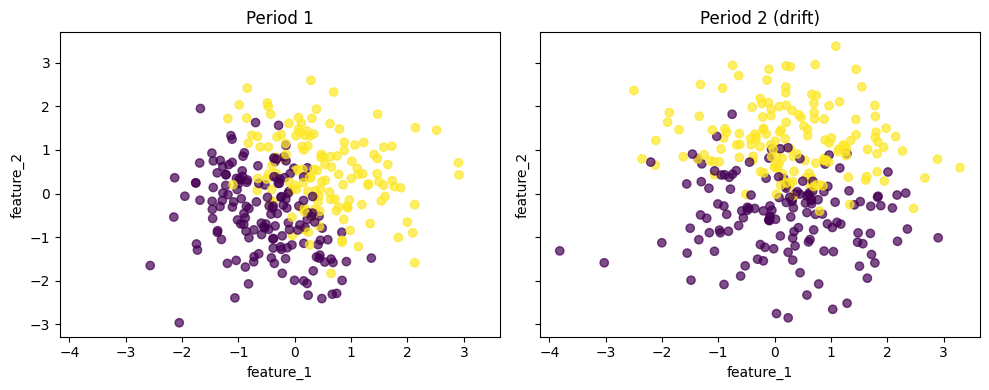

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
axes[0].scatter(period1['feature_1'], period1['feature_2'], c=period1['target'], alpha=0.7)
axes[0].set_title('Period 1')
axes[1].scatter(period2['feature_1'], period2['feature_2'], c=period2['target'], alpha=0.7)
axes[1].set_title('Period 2 (drift)')
for ax in axes:
    ax.set_xlabel('feature_1')
    ax.set_ylabel('feature_2')
plt.tight_layout(); plt.show()

## Train on Period 1, evaluate on Period 1 and Period 2

In [5]:
X1 = period1[['feature_1', 'feature_2']]
y1 = period1['target']
X2 = period2[['feature_1', 'feature_2']]
y2 = period2['target']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=42, stratify=y1)

drift_model = LogisticRegression(max_iter=1000)
drift_model.fit(X1_train, y1_train)

pred_p1 = drift_model.predict(X1_test)
pred_p2 = drift_model.predict(X2)

drift_cmp = pd.DataFrame([
    {'Evaluation period': 'Period 1 test', 'Accuracy': accuracy_score(y1_test, pred_p1), 'Precision': precision_score(y1_test, pred_p1), 'Recall': recall_score(y1_test, pred_p1), 'F1': f1_score(y1_test, pred_p1)},
    {'Evaluation period': 'Period 2 full', 'Accuracy': accuracy_score(y2, pred_p2), 'Precision': precision_score(y2, pred_p2), 'Recall': recall_score(y2, pred_p2), 'F1': f1_score(y2, pred_p2)},
])
display(drift_cmp.round(3))

,Evaluation period,Accuracy,Precision,Recall,F1
0,Period 1 test,0.878,0.860,0.881,0.871
1,Period 2 full,0.717,0.673,0.877,0.762


If performance drops on new data, this may indicate concept drift.

Simple responses:
- monitor performance continuously
- retrain on recent data
- use sliding windows
- compare old and new models

## Model selection on real dataset (Week 3 shared dataset)

In [6]:
if DATASET_PATH.exists():
    df = pd.read_csv(DATASET_PATH)
else:
    from sklearn.datasets import load_breast_cancer
    d = load_breast_cancer()
    df = pd.DataFrame(d.data, columns=d.feature_names)
    df['target'] = d.target
    df.to_csv(DATASET_PATH, index=False)

X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
}

rows = []
proba = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
    })
    proba[name] = model.predict_proba(X_test)[:, 1]

model_cmp = pd.DataFrame(rows)

a_rows = []
for name in models:
    auc = roc_auc_score(y_test, proba[name])
    a_rows.append({'Model': name, 'ROC-AUC': auc})
auc_df = pd.DataFrame(a_rows)

final_cmp = model_cmp.merge(auc_df, on='Model')
display(final_cmp.round(3))

/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.956,0.959,0.972,0.966,0.996
1,Decision Tree,0.939,0.958,0.944,0.951,0.934
2,KNN,0.930,0.944,0.944,0.944,0.952


Model selection depends on performance metrics, interpretability, speed, and real-world error costs.

## ROC curves and AUC

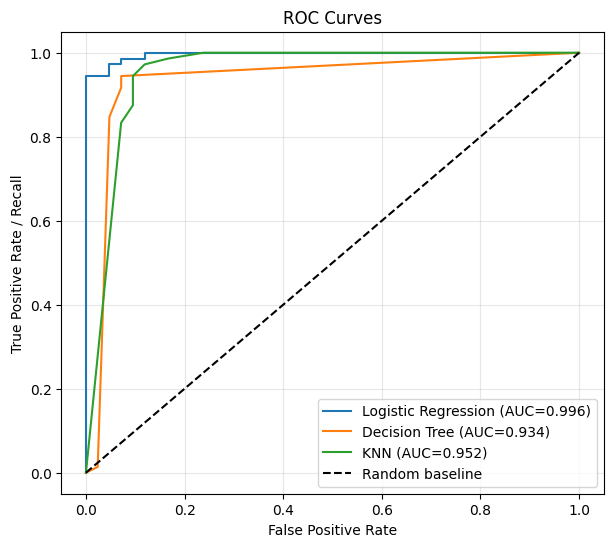

In [8]:
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    auc = roc_auc_score(y_test, proba[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Threshold analysis (Logistic Regression)
Lower threshold often raises recall, higher threshold often raises precision.

In [9]:
log_model = models['Logistic Regression']
log_proba = proba['Logistic Regression']

thr_rows = []
for thr in [0.3, 0.5, 0.7]:
    pred_thr = (log_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_thr).ravel()
    thr_rows.append({
        'Threshold': thr,
        'Precision': precision_score(y_test, pred_thr),
        'Recall': recall_score(y_test, pred_thr),
        'F1': f1_score(y_test, pred_thr),
        'False Positives': fp,
        'False Negatives': fn,
    })

thr_df = pd.DataFrame(thr_rows)
display(thr_df.round(3))

,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.3,0.934,0.986,0.959,5,1
1,0.5,0.959,0.972,0.966,3,2
2,0.7,0.971,0.944,0.958,2,4


## Hyperparameter tuning mindset
- KNN: `n_neighbors`
- Decision Tree: `max_depth`
- Logistic Regression: `C`

Tune on validation/CV, not on final test set.

## Mini GridSearch examples

In [10]:
knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': [3,5,7,9,11]}, cv=5, scoring='f1')
knn_grid.fit(X_train, y_train)

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {'max_depth': [2,3,4,5,6,None]}, cv=5, scoring='f1')
dt_grid.fit(X_train, y_train)

print('Best KNN params:', knn_grid.best_params_, '| best CV F1:', round(knn_grid.best_score_, 3))
print('Best Tree params:', dt_grid.best_params_, '| best CV F1:', round(dt_grid.best_score_, 3))

Best KNN params: {'n_neighbors': 5} | best CV F1: 0.95
Best Tree params: {'max_depth': 4} | best CV F1: 0.951


## Final model comparison table

In [11]:
best_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': dt_grid.best_estimator_,
    'KNN': knn_grid.best_estimator_,
}

rows = []
for name, model in best_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    rows.append({
        'Model': name,
        'Best hyperparameters': str(model.get_params()),
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': auc,
    })

final_table = pd.DataFrame(rows)
display(final_table[['Model','Accuracy','Precision','Recall','F1','ROC-AUC']].round(3))

/Users/mehrdadjalali/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.956,0.959,0.972,0.966,0.996
1,Decision Tree,0.939,0.958,0.944,0.951,0.934
2,KNN,0.912,0.943,0.917,0.930,0.956


## Final interpretation
Choose model based on metric priorities, error costs, and interpretability.

Questions:
- Which model would you choose and why?
- Which metric supports your choice?
- Is there any overfitting signal?
- Would it still work if data drifts?

## Student tasks
1. Change threshold and compare precision/recall.
2. Try another hyperparameter value.
3. Explain ROC-AUC in your own words.
4. Give one real-world concept drift example.
5. Write a non-technical summary of your chosen model.

In [12]:
print('Week 3 Day 3 Concept Drift, Model Selection, ROC-AUC completed successfully.')

Week 3 Day 3 Concept Drift, Model Selection, ROC-AUC completed successfully.
